# Loan Approval Model: Train and Deploy

This notebook creates the exact model bundle loaded by the Day 5 FastAPI service.


## my goal

Generate reproducible training data, evaluate an explainable classifier, save it, and verify a prediction before deployment.


## 1. imports


In [1]:
from pathlib import Path
import sys
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

BACKEND_DIR = Path("day_5/deployment/backend")
if not BACKEND_DIR.exists():
    BACKEND_DIR = Path("../deployment/backend")
sys.path.insert(0, str(BACKEND_DIR.resolve()))

from train_model import FEATURES, generate_dataset, train_model

MODEL_PATH = BACKEND_DIR / "model" / "loan_model.joblib"
sns.set_theme(style="whitegrid", context="notebook")

## 2. Generate the training data

A fixed random seed makes the dataset reproducible.


In [2]:
loan_data = generate_dataset(rows=4000, random_state=42)
print(f"Rows: {len(loan_data):,} | Approval rate: {loan_data['approved'].mean():.1%}")
loan_data.head()

Rows: 4,000 | Approval rate: 44.4%


,income,age,loan_amount,credit_score,existing_debt,approved
0,24371,35,53441,579,49825,0
1,96266,58,58708,550,27966,1
2,83730,22,25064,339,1924,0
3,61082,41,31784,365,44887,0
4,60467,57,75879,628,47527,0


The data is synthetic and intended only for deployment training. It must not be used for real credit decisions.


## 3. Train and save the model


In [3]:
bundle, loan_data = train_model(MODEL_PATH, random_state=42)
pd.Series(bundle["metrics"], name="Value").to_frame()

,Value
accuracy,0.9375
roc_auc,0.9866
training_rows,3200.0000
test_rows,800.0000
approval_rate,0.4440


In [4]:
print("Saved model:", MODEL_PATH.resolve())
print(f"File size: {MODEL_PATH.stat().st_size / 1024:.1f} KB")

Saved model: D:\development\sdc_traing_2026\day_5\deployment\backend\model\loan_model.joblib
File size: 2.0 KB


## 4. Inspect model coefficients

Positive values support approval; negative values work against it.


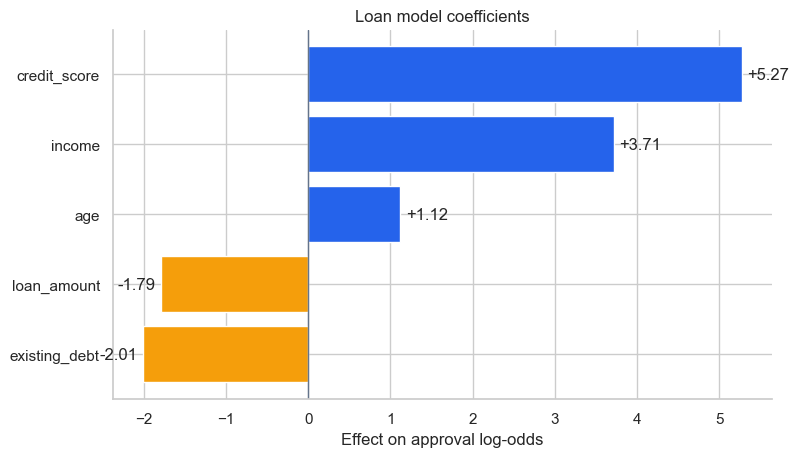

In [5]:
pipeline = bundle["model"]
coefficients = pd.Series(
    pipeline.named_steps["classifier"].coef_[0],
    index=FEATURES, name="Coefficient"
).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bar_colors = ["#F59E0B" if value < 0 else "#2563EB" for value in coefficients]
bars = ax.barh(coefficients.index, coefficients.values, color=bar_colors)
ax.bar_label(bars, fmt="%+.2f", padding=4)
ax.axvline(0, color="#64748B", linewidth=1)
ax.set(title="Loan model coefficients", xlabel="Effect on approval log-odds", ylabel="")
sns.despine()
plt.show()

## 5. Test one prediction


In [6]:
applicant = pd.DataFrame([{
    "income": 65_000,
    "age": 34,
    "loan_amount": 25_000,
    "credit_score": 690,
    "existing_debt": 8_000,
}])[FEATURES]

approval_probability = pipeline.predict_proba(applicant)[0, 1]
decision = "Approved" if approval_probability >= 0.5 else "Declined"
print("Decision:", decision)
print(f"Approval probability: {approval_probability:.1%}")

Decision: Approved
Approval probability: 99.6%


## 6. Explain the prediction

Because this is scaled logistic regression, each contribution is exact in the model's log-odds calculation.


In [7]:
scaled_applicant = pipeline.named_steps["scaler"].transform(applicant)[0]
contributions = pd.Series(
    scaled_applicant * pipeline.named_steps["classifier"].coef_[0],
    index=FEATURES, name="Contribution"
).sort_values()
contributions.to_frame().round(3)

,Contribution
age,-0.727
income,-0.382
loan_amount,1.476
existing_debt,2.315
credit_score,3.879


## 7. Verify the saved file


In [8]:
loaded_bundle = joblib.load(MODEL_PATH)
loaded_probability = loaded_bundle["model"].predict_proba(applicant)[0, 1]
assert np.isclose(approval_probability, loaded_probability)
print("Saved model loaded successfully and returned the same prediction.")

Saved model loaded successfully and returned the same prediction.


## Run the application

From `day_5/deployment`, run:

```powershell
docker compose up --build
```

Open `http://localhost:3000` for the Next.js interface or `http://localhost:8000/docs` for the API documentation.


## my lessons learned

- The notebook and API use the same saved model bundle.
- Scaling and classification are stored together in one pipeline.
- The API returns a decision, probability and exact feature contributions.
- Docker Compose starts the model API and Next.js interface together.
